In [1]:
import ast
import inspect
import qsample as qs
import matplotlib.pyplot as plt
import stim


class ProtocolTranslator(ast.NodeTransformer):
    def __init__(self, fault_tolerant=False):

        self.check_functions = {}
        self.mapping = {}
        
        self.last_functions = []  
        self.condition_stack = ["True"]

        self.protocol = qs.Protocol(check_functions=self.check_functions, fault_tolerant=fault_tolerant)

    def is_stim_circuit_def(self, node):
        if not isinstance(node, ast.Call):
            return False

        f = node.func
        return (
            isinstance(f, ast.Attribute)
            and isinstance(f.value, ast.Name)
            and f.value.id == "stim"
            and f.attr == "Circuit"
        )

    def is_do_circuit(self, node):
        return (
            isinstance(node, ast.Call)
            and isinstance(node.func, ast.Attribute)
            and node.func.attr == "do_circuit"
        )
    
    def is_current_measurement(self, node):
        return (
            isinstance(node, ast.Call)
            and isinstance(node.func, ast.Attribute)
            and node.func.attr == "current_measurement_record"
        )
    
    def visit_Assign(self, node): # MUDAR AQUI DE LAST_CIRCUIT PARA O CIRCUITO QUE DE FATO RODA
        self.collect_circuit(node.targets, node.value)
        if self.last_functions and self.is_current_measurement(node.value):
            target = node.targets[0]
            if isinstance(target, ast.Name):
                self.mapping[target.id] = self.last_functions[0]

        return self.generic_visit(node)

    def visit_If(self, node):
        self.visit(node.test)
        cond_src = ast.unparse(node.test)
        before_if = self.last_functions.copy()
        self.condition_stack[-1]=cond_src


        if isinstance(node.test, ast.Call): # Selects check_functions
            if isinstance(node.test.func, ast.Name):
                    func_name = node.test.func.id
                    real_func = self.globals[func_name]
                    self.check_functions[func_name] = real_func



        
        for stmt in node.body:
            self.visit(stmt)
        after_if = self.last_functions.copy()
        after_if_conds = self.condition_stack.copy()
        
        # ELSE 

        cond_src = f"not {cond_src}"
        self.last_functions = before_if.copy()
        self.condition_stack[-1]=cond_src
    
        has_else=False
        for stmt in node.orelse:
            has_else=True
            self.visit(stmt)

        after_else = self.last_functions.copy()
        after_else_conds = self.condition_stack.copy()
        
        if has_else:
            self.last_functions = after_if + after_else
            self.condition_stack = after_if_conds + after_else_conds
        else:
            self.last_functions = before_if + after_if
            self.condition_stack = [cond_src] + after_if_conds
        return node

    def visit_Expr(self, node):
        if isinstance(node.value, ast.Call) and self.is_do_circuit(node.value):
            if node.value.args and isinstance(node.value.args[0], ast.Name):
                circuit_name = node.value.args[0].id
                if not self.last_functions:
                    self.protocol.add_edge("START", circuit_name, check="True")
                else:
                    for protocol_node, protocol_check in zip(self.last_functions, self.condition_stack):
                        self.protocol.add_edge(protocol_node, circuit_name, check=protocol_check)
                self.last_functions=[circuit_name]
                self.condition_stack=["True"]

        return self.generic_visit(node)
    
    
    def visit_Return(self, node):
        if isinstance(node.value, ast.Constant):
            if node.value.value == "FAIL":
                for protocol_node, protocol_check in zip(self.last_functions, self.condition_stack):
                        self.protocol.add_edge(protocol_node, "FAIL", check=protocol_check)
        self.generic_visit(node)

    def visit_Name(self, node):
        if node.id in self.mapping.keys() and isinstance(node.ctx, ast.Load):
            return ast.copy_location(ast.Name(id=self.mapping[node.id], ctx=node.ctx), node)
        return node
    

    def collect_circuit(self, targets, value):
        if self.is_stim_circuit_def(value):
            for t in targets:
                if isinstance(t, ast.Name):
                    circuit_name=t.id

            if value.args and isinstance(value.args[0], ast.Constant) and isinstance(value.args[0].value, str):
                circuit_text = value.args[0].value
                try:
                    circuit = qs.Circuit().from_stim_circuit(circuit_text)
                    self.protocol.add_node(circuit_name, circuit=circuit)
                    
                    
                except Exception as e:
                    print(f"Failed to parse stim.Circuit at line {value.lineno}: {e}")


/Users/jhfontes/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def to_qsample_protocol(code):
    code = inspect.getsource(code)
    tree = ast.parse(code)
    collector = ProtocolTranslator()
    collector.globals = globals()
    collector.visit(tree)
    return collector

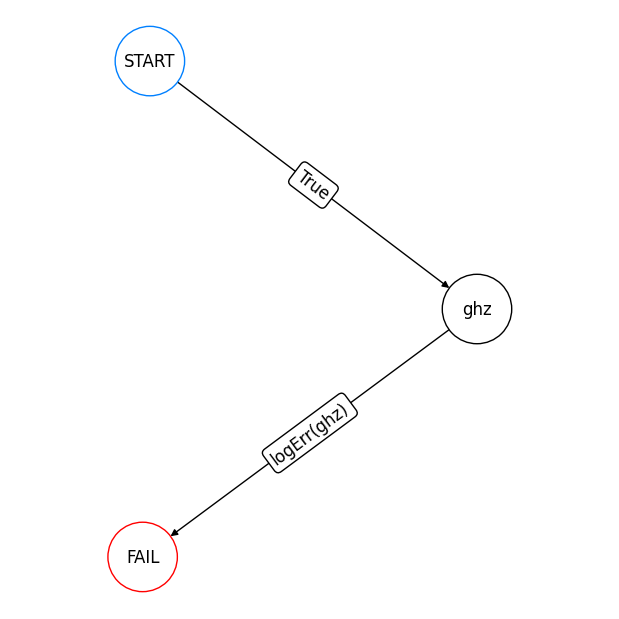

In [3]:
def logErr(msmt_list):
        return msmt_list[-1] == 1

def protocol():

    ghz = stim.Circuit('''
    H 0
    CX 0 1 1 2 2 3 3 4 0 4
    M 4
    ''')

    sim = stim.TableauSimulator()
    sim.do_circuit(ghz)
    result = sim.current_measurement_record()

    if logErr(result):
        return "FAIL"
    

ghz = to_qsample_protocol(protocol).protocol
ghz.draw()

p=('1.00e-02',): 100%|██████████| 1000/1000 [00:00<00:00, 9871.58it/s]
/var/folders/dd/4yhpjrt92t3fr6_cq5glj9b80000gn/T/ipykernel_95096/1366320983.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'logical p')

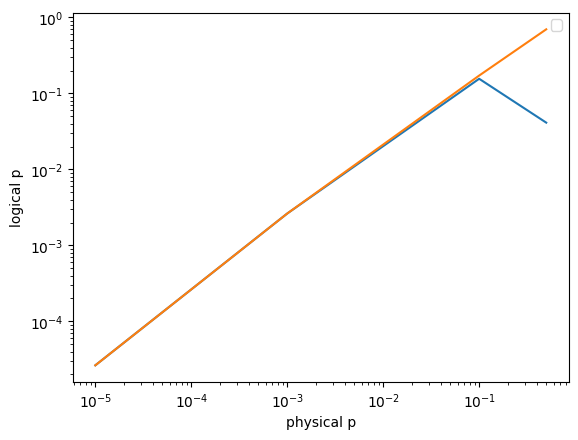

In [4]:
err_model = qs.noise.E1
q = [1e-5, 1e-3, 1e-1, 0.5]
err_params = {'q': q}

ss_sam = qs.SubsetSampler(protocol=ghz, simulator=qs.StimSimulator,  p_max={'q': 0.01}, err_model=err_model, err_params=err_params, L=3)
ss_sam.run(1000)

stats = ss_sam.stats()
plt.plot(q, stats[0])
plt.plot(q, stats[2])


plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('physical p')
plt.ylabel('logical p')